In [1]:
import time
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.linear_model import LinearRegression
from sklearn import tree
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import math
from prettytable import PrettyTable

Описание датасета:

Данные предоставлены Taxi and Limousine Commission (TLC) по городу Нью-Йорку и его окресностям о поездках в такси.
Каждая строка представляет собой одну поездку в такси. Записи о поездках включают поля даты/время посадки и высадки, местоположения зон посадки и высадки такси, расстояния поездок, детализированные тарифы, типы тарифов, типы оплаты и количество пассажиров, сообщенное водителем.

Список переменных тип данных и описание:
| № | Название переменной         | Тип данных       | Описание |
|---|-----------------------------|------------------|----------|
| 1 | `VendorID`                  | int              | Идентификатор поставщика (компании-таксопарка), который предоставил данные о поездке. |
| 2 | `tpep_pickup_datetime`      | datetime         | Дата и время начала поездки (Trip Pickup Exact Time). |
| 3 | `tpep_dropoff_datetime`     | datetime         | Дата и время окончания поездки (Trip Dropoff Exact Time). |
| 4 | `passenger_count`           | int              | Количество пассажиров в такси во время поездки. |
| 5 | `trip_distance`             | float            | Пройденное расстояние поездки в милях. |
| 6 | `pickup_longitude`          | float            | Географическая долгота точки подачи такси. |
| 7 | `pickup_latitude`           | float            | Географическая широта точки подачи такси. |
| 8 | `RateCodeID`                | int              | Идентификатор тарифа. <br>1 = Standard rate<br>2 = JFK<br>3 = Newark<br>4 = EWR<br>5 = Negotiated fare<br>6 = Group ride |
| 9 | `store_and_fwd_flag`        | string (Y/N)     | Указывает, сохранялась ли поездка в памяти автомобиля перед отправкой в систему (Y = да, N = нет). |
| 10 | `dropoff_longitude`        | float            | Географическая долгота точки завершения поездки. |
| 11 | `dropoff_latitude`         | float            | Географическая широта точки завершения поездки. |
| 12 | `payment_type`             | int              | Тип оплаты:<br>1 = Credit card<br>2 = Cash<br>3 = No charge<br>4 = Dispute<br>5 = Unknown<br>6 = Voided trip |
| 13 | `fare_amount`              | float            | Основная стоимость поездки без дополнительных сборов и чаевых. |
| 14 | `extra`                    | float            | Дополнительные сборы, например за ночное время или праздники. |
| 15 | `mta_tax`                  | float            | Налог MTA (Metropolitan Transportation Authority), применяемый к каждой поездке в Нью-Йорке. Обычно фиксированная сумма. |
| 16 | `tip_amount`               | float            | Сумма чаевых, оставленных пассажиром. |
| 17 | `tolls_amount`             | float            | Сумма платы за проезд по платным дорогам/мостам во время поездки. |
| 18 | `improvement_surcharge`    | float            | Сбор за улучшение инфраструктуры (обычно фиксированная сумма). |
| 19 | `total_amount`             | float            | Общая сумма, уплаченная за поездку, включая все сборы, налоги, чаевые и плату за проезд. |

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

base_path = "./"

df_2016_1 = pd.read_csv(f'{base_path}yellow_tripdata_2016-01.csv', nrows=1000000)
df_2016_2 = pd.read_csv(f'{base_path}yellow_tripdata_2016-02.csv', nrows=1000000)
df_2016_3 = pd.read_csv(f'{base_path}yellow_tripdata_2016-03.csv', nrows=1000000)

df = pd.concat([df_2016_1,df_2016_2,df_2016_3], ignore_index=True)

if 'tpep_pickup_datetime' in df.columns:
    df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
    df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
    df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek  # 0 - понедельник
    df['pickup_month'] = df['tpep_pickup_datetime'].dt.month

# Описательные статистики для числовых переменных
print("📊 2. Описательные статистики для числовых переменных:")
numeric_df = df.select_dtypes(include=[np.number])
print(numeric_df.describe().T)
print("\n")



📊 2. Описательные статистики для числовых переменных:
                           count       mean          std         min  \
VendorID               3000000.0   1.545147     0.497958    1.000000   
passenger_count        3000000.0   1.676695     1.330724    0.000000   
trip_distance          3000000.0   4.602068  2886.751981    0.000000   
pickup_longitude       3000000.0 -72.896918     8.856490 -121.933327   
pickup_latitude        3000000.0  40.158853     4.878836    0.000000   
RatecodeID             3000000.0   1.040116     0.541711    1.000000   
dropoff_longitude      3000000.0 -72.954789     8.620494 -121.933327   
dropoff_latitude       3000000.0  40.191087     4.749051    0.000000   
payment_type           3000000.0   1.359128     0.494839    1.000000   
fare_amount            3000000.0  12.540121    11.067051 -300.000000   
extra                  3000000.0   0.289425     0.414564  -58.500000   
mta_tax                3000000.0   0.497574     0.050831   -1.000000   
tip_amount

In [3]:
# Количество пропусков
print("🚫 Пропущенные значения:")
print(df.isnull().sum())
print("\n")

🚫 Пропущенные значения:
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RatecodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
pickup_hour              0
pickup_dayofweek         0
pickup_month             0
dtype: int64




🔗 5. Корреляционная матрица:


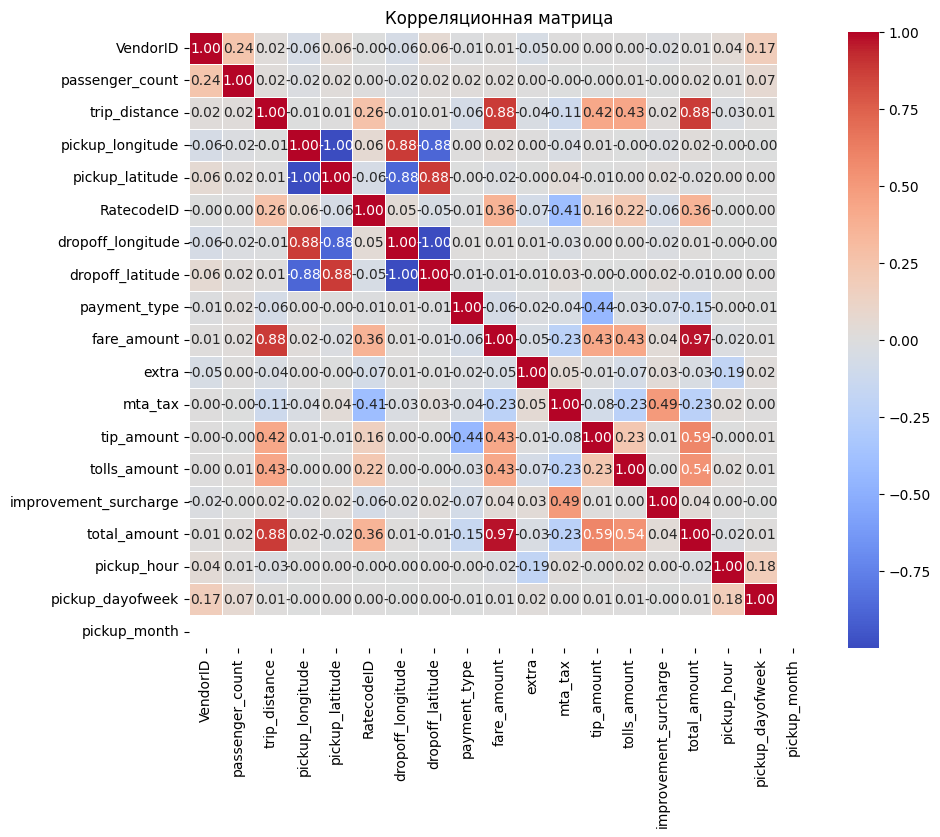

In [3]:
# Корреляционная матрица
print("🔗 5. Корреляционная матрица:")
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Корреляционная матрица')
plt.show()

In [4]:
df.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,...,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,pickup_hour,pickup_dayofweek,pickup_month
0,2,2016-01-01,2016-01-01 00:00:00,2,1.10,-73.990372,40.734695,1,N,-73.981842,...,7.5,0.5,0.5,0.0,0.0,0.3,8.8,0,4,1
1,2,2016-01-01,2016-01-01 00:00:00,5,4.90,-73.980782,40.729912,1,N,-73.944473,...,18.0,0.5,0.5,0.0,0.0,0.3,19.3,0,4,1
2,2,2016-01-01,2016-01-01 00:00:00,1,10.54,-73.984550,40.679565,1,N,-73.950272,...,33.0,0.5,0.5,0.0,0.0,0.3,34.3,0,4,1
3,2,2016-01-01,2016-01-01 00:00:00,1,4.75,-73.993469,40.718990,1,N,-73.962242,...,16.5,0.0,0.5,0.0,0.0,0.3,17.3,0,4,1
4,2,2016-01-01,2016-01-01 00:00:00,3,1.76,-73.960625,40.781330,1,N,-73.977264,...,8.0,0.0,0.5,0.0,0.0,0.3,8.8,0,4,1


In [ ]:
# Гистограммы числовых переменных
print("Распределение числовых переменных:")
numeric_cols_list = numeric_df.columns
fig, axes = plt.subplots(nrows=(len(numeric_cols_list)+3)//4, ncols=4, figsize=(16, 3 * ((len(numeric_cols_list)+3)//4)))
for i, col in enumerate(numeric_cols_list):
    sns.histplot(df[col], ax=axes[i//4, i%4], kde=True)
plt.tight_layout()
plt.show()

Распределение числовых переменных:


📦 Boxplot для fare_amount и trip_distance:


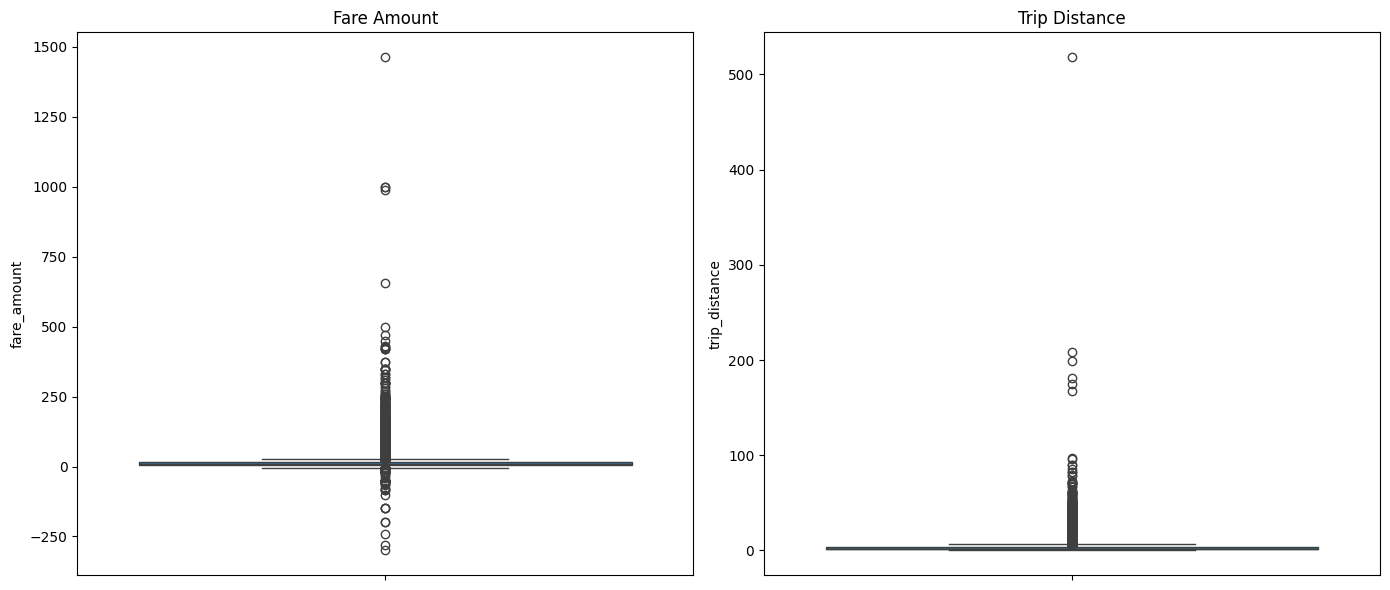

In [7]:
# Boxplot для основных метрик
print("📦 Boxplot для fare_amount и trip_distance:")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(y=df['fare_amount'], ax=axes[0])
sns.boxplot(y=df['trip_distance'], ax=axes[1])
axes[0].set_title('Fare Amount')
axes[1].set_title('Trip Distance')
plt.tight_layout()
plt.show()


🕒 Анализ по времени (час начала поездки):


C:\Users\user\AppData\Local\Temp\ipykernel_13076\2419409365.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pickup_hour', data=df, palette='viridis')


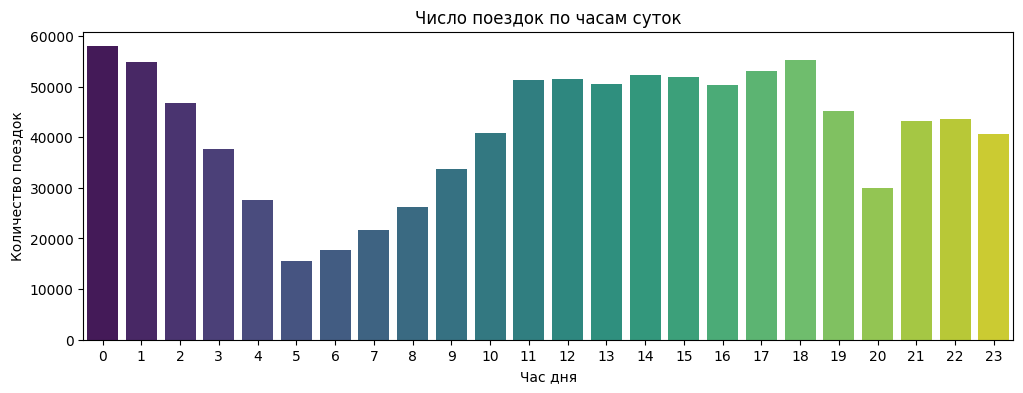

In [ ]:
# Анализ времени
if 'pickup_hour' in df.columns:
    print("🕒 Анализ по времени (час начала поездки):")
    plt.figure(figsize=(12, 4))
    sns.countplot(x='pickup_hour', data=df, palette='viridis')
    plt.title('Число поездок по часам суток')
    plt.xlabel('Час дня')
    plt.ylabel('Количество поездок')
    plt.show()

In [ ]:
#Берем только нужные переменные
columns=['tpep_pickup_datetime',
           'tpep_dropoff_datetime',
           'trip_distance',
           'pickup_longitude',
           'pickup_latitude',
           'dropoff_longitude',
           'dropoff_latitude',
           'total_amount']

df_2016_1 = pd.read_csv(f'{base_path}yellow_tripdata_2016-01.csv', usecols=columns, nrows=1000000)
df_2016_2 = pd.read_csv(f'{base_path}yellow_tripdata_2016-02.csv', usecols=columns, nrows=1000000)
df_2016_3 = pd.read_csv(f'{base_path}yellow_tripdata_2016-03.csv', usecols=columns, nrows=1000000)

df = pd.concat([df_2016_1,df_2016_2,df_2016_3], ignore_index=True)

original_len = df.shape[0]
print(original_len)

3000000


Подготовка данных, создадим новые фичи для модели.

In [ ]:
def clean_data(df, test=False, predict=False):
    initial_len = len(df)
    print(f"🧾 Всего записей: {initial_len}")
    
    # Удаление строк с пропущенными значениями
    df_clean = df.dropna(how='any', axis='rows')
    removed_na = len(df) - len(df_clean)
    print(f"🚫 Удалено из-за пропусков: {removed_na} ({removed_na / initial_len:.2%})")

    # Удаление нулевых координат pickup
    before_pickup = len(df_clean)
    df_clean = df_clean[(df_clean.pickup_latitude != 0) | (df_clean.pickup_longitude != 0)]
    removed_pickup = before_pickup - len(df_clean)
    print(f"📍 Удалено из-за нулевых pickup координат: {removed_pickup} ({removed_pickup / initial_len:.2%})")

    # Удаление нулевых координат dropoff
    before_dropoff = len(df_clean)
    df_clean = df_clean[(df_clean.dropoff_latitude != 0) | (df_clean.dropoff_longitude != 0)]
    removed_dropoff = before_dropoff - len(df_clean)
    print(f"🏁 Удалено из-за нулевых dropoff координат: {removed_dropoff} ({removed_dropoff / initial_len:.2%})")

    # Фильтрация по total_amount
    if "total_amount" in df_clean.columns:
        before_amount = len(df_clean)
        df_clean = df_clean[df_clean.total_amount.between(5, 45)]
        removed_amount = before_amount - len(df_clean)
        print(f"💰 Удалено из-за total_amount вне диапазона [5, 45]: {removed_amount} ({removed_amount / initial_len:.2%})")
    
    final_len = len(df_clean)
    print(f"✅ Осталось записей: {final_len} ({final_len / initial_len:.2%} от исходного объёма)")
    
    return df_clean

df = clean_data(df)

🧾 Всего записей: 3000000
🚫 Удалено из-за пропусков: 0 (0.00%)
📍 Удалено из-за нулевых pickup координат: 43632 (1.45%)
🏁 Удалено из-за нулевых dropoff координат: 4148 (0.14%)
💰 Удалено из-за total_amount вне диапазона [5, 45]: 200768 (6.69%)
✅ Осталось записей: 2751452 (91.72% от исходного объёма)


### 2. Уберем поздки более 3 часов и удалим ошибочные данные (где время меньше 0).

In [ ]:
def clean_trip_duration(df):
    # Преобразуем колонки в datetime
    df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
    df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

    # Вычисляем длительность поездки в минутах
    trip_duration = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
    df['trip_duration'] = trip_duration.astype(float)

    initial_len = len(df)

    # Фильтруем и удаляем некорректные поездки
    removed_idx = df[(df['trip_duration'] > 180) | (df['trip_duration'] <= 0)].index
    removed_count = len(removed_idx)
    
    print(f"🕒 Удалено из-за некорректной длительности поездки: {removed_count} ({removed_count / initial_len:.2%})")

    df.drop(removed_idx, inplace=True)

    return df


clean_trip_duration(df)

🕒 Удалено из-за некорректной длительности поездки: 4321 (0.16%)


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,total_amount,trip_duration
5,2016-01-01 00:00:00,2016-01-01 00:18:30,5.52,-73.980118,40.743050,-73.913490,40.763142,20.30,18.500000
6,2016-01-01 00:00:00,2016-01-01 00:26:45,7.45,-73.994057,40.719990,-73.966362,40.789871,27.30,26.750000
7,2016-01-01 00:00:01,2016-01-01 00:11:55,1.20,-73.979424,40.744614,-73.992035,40.753944,10.30,11.900000
8,2016-01-01 00:00:02,2016-01-01 00:11:14,6.00,-73.947151,40.791046,-73.920769,40.865578,19.30,11.200000
9,2016-01-01 00:00:02,2016-01-01 00:11:08,3.21,-73.998344,40.723896,-73.995850,40.688400,12.80,11.100000
...,...,...,...,...,...,...,...,...,...
2999995,2016-03-03 10:05:31,2016-03-03 10:10:50,0.48,-73.989754,40.741730,-73.997780,40.745060,7.56,5.316667
2999996,2016-03-03 10:05:31,2016-03-03 10:16:09,1.90,-73.992989,40.747952,-74.009064,40.730564,10.80,10.633333
2999997,2016-03-03 10:05:31,2016-03-03 10:12:05,1.14,-74.005898,40.740231,-74.007393,40.727379,8.76,6.566667
2999998,2016-03-03 10:05:31,2016-03-03 10:31:45,5.65,-73.979996,40.754536,-74.011726,40.704472,27.96,26.233333


### 3. Переименуем переменную

In [ ]:
def clean_pickuptime(df):
    return df.rename(columns={'tpep_pickup_datetime': 'pickup_time'})

df = clean_pickuptime(df)

### 4. Переведем мили в километры и уберем значения где у поездок расстояние менее 0 и более 40 км.

In [ ]:
def clean_trip_distance(df):
    df['trip_distance']=df['trip_distance']*1.61
    df.drop(df[(df['trip_distance'] <= 0) | (df['trip_distance'] > 40)].index, inplace = True)
    
# clean_trip_distance(df_2015)
clean_trip_distance(df)

### 5. Посчитаем скорость и уберем аномальные данные

In [ ]:
def compute_speed(df):
    df['speed'] = df['trip_distance']/df['trip_duration']*60
    
def clean_speed(df):

    df.drop(df[((df['speed'] <= 0) | (df['speed'] > 120))].index, inplace = True)


compute_speed(df)    
clean_speed(df)



### 6. Определим кластеры по региону поездок


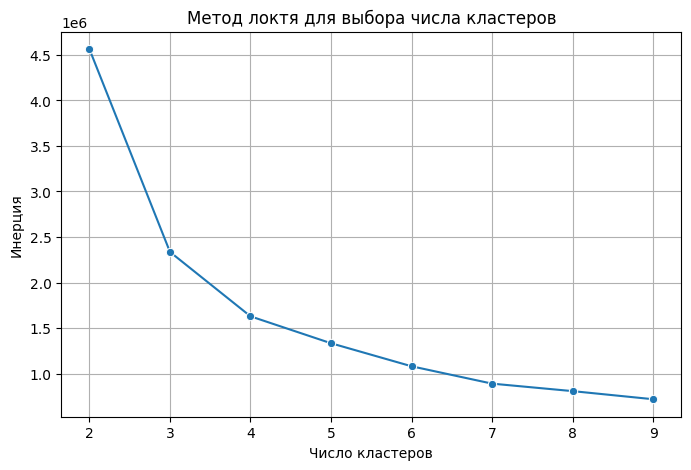

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Выбираем признаки для кластеризации
features = ['pickup_longitude', 'pickup_latitude']
X = df[features]

# Нормализация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Определение оптимального числа кластеров (метод локтя)
inertias = []
k_range = range(2, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
sns.lineplot(x=k_range, y=inertias, marker='o')
plt.title('Метод локтя для выбора числа кластеров')
plt.xlabel('Число кластеров')
plt.ylabel('Инерция')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Вычисление силуэта для разных k
k_range = range(2, 11)  # проверяем от 2 до 10 кластеров
silhouette_scores = []

# Выбираем признаки для кластеризации
features = ['pickup_longitude', 'pickup_latitude']
X = df[features]

# Нормализация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for k in k_range:
    kmeans = MiniBatchKMeans(n_clusters = k, batch_size = 1000)
    cluster_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)
    print(f"Clusters: {k}, Silhouette Score: {score:.4f}")

# Визуализация результатов
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Метод силуэта для выбора числа кластеров')
plt.xlabel('Число кластеров')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.xticks(k_range)
plt.show()

# Вывод лучшего числа кластеров 
best_k = k_range[np.argmax(silhouette_scores)]
print(f"\n✅ Наилучшее число кластеров: {best_k} (Silhouette Score = {max(silhouette_scores):.4f})")

На основании методов локтя и силуэта определим определим оптимальное число кластеров.

Аналитика по кластерам:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler


# Обучение KMeans на лучшем числе кластеров
kmeans = MiniBatchKMeans(n_clusters = best_k, batch_size = 1000)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Визуализация силуэта по кластерам
plt.figure(figsize=(10, 6))
y_lower = 10
for i in range(best_k):
    ith_cluster_silhouette_values = silhouette_samples(X_scaled, df['cluster'])
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = plt.cm.Spectral(float(i) / best_k)
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                       0, ith_cluster_silhouette_values,
                       facecolor=color, edgecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.title("Силуэт для каждого кластера")
plt.xlabel("Значение силуэта")
plt.ylabel("Номер кластера")
plt.axvline(x=np.mean(silhouette_scores), color="red", linestyle="--")
plt.yticks([])
plt.show()

# Графики кластеров 

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Карта кластеров
sns.scatterplot(data=df, x='pickup_longitude', y='pickup_latitude',
                hue='cluster', palette='viridis', s=15, alpha=0.6, ax=axes[0, 0])
axes[0, 0].set_title('Кластеры точек подачи такси')
axes[0, 0].set_xlabel('Долгота')
axes[0, 0].set_ylabel('Широта')

# Тепловая карта плотности точек
sns.kdeplot(data=df, x='pickup_longitude', y='pickup_latitude',
            fill=True, cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Плотность точек подачи')


plt.tight_layout()
plt.show()

print("\n🔢 Количество записей в каждом кластере:")
print(df['cluster'].value_counts().sort_index())

In [ ]:
from pandarallel import pandarallel
import pandas as pd

pandarallel.initialize()  

def process_time(x):
    import pandas as pd
    from datetime import timedelta
    return pd.to_datetime(x).replace(minute=0, second=0) + timedelta(hours=1)

df['pickup_time'] = df['pickup_time'].parallel_apply(process_time)

INFO: Pandarallel will run on 10 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.

https://nalepae.github.io/pandarallel/troubleshooting/


Соберем обучающий датасет: 

Зависимая переменная(спрос) - количество поездок (count)
Объясняющие переменные - день, месяц, день недели, час

In [ ]:
from pandarallel import pandarallel
from functools import partial
import pandas as pd

# Initialize pandarallel
pandarallel.initialize()

# Groupby and reset index
df = df.groupby(['pickup_time', 'cluster']).size().reset_index(name='count')

# Compute max count
max_count = df['count'].max()

# Define the function explicitly with all needed variables
def normalize_count(x, max_count):
    return x / max_count

# Create a partially applied function with max_count baked in
func = partial(normalize_count, max_count=max_count)

# Apply in parallel
df['count'] = df['count'].parallel_apply(func)

# Extract datetime features
df['month'] = pd.DatetimeIndex(df['pickup_time']).month
df['day'] = pd.DatetimeIndex(df['pickup_time']).day
df['dayofweek'] = pd.DatetimeIndex(df['pickup_time']).dayofweek
df['hour'] = pd.DatetimeIndex(df['pickup_time']).hour

INFO: Pandarallel will run on 10 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.

https://nalepae.github.io/pandarallel/troubleshooting/


### 7. Разделение на тестовую и обучающую выборки

In [ ]:
from sklearn.model_selection import train_test_split
# training X and y
X = df[['cluster', 'month', 'day', 'hour', 'dayofweek']]
y = df['count']


X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.33, random_state=42
)

Линейная регрессия

In [ ]:
LReg = LinearRegression()
LReg.fit(X_train, y_train)
LReg_y_pred = LReg.predict(X_test)

Случайный лес

In [ ]:
RFRegr = RandomForestRegressor()
RFRegr.fit(X_train, y_train)
RFRegr_y_pred = RFRegr.predict(X_test)

XGBoost

In [ ]:
GBRegr = XGBRegressor(n_estimators=1000, max_depth=7, eta=0.1, subsample=0.7, colsample_bytree=0.8)
GBRegr.fit(X_train, y_train)
GBRegr_y_pred = GBRegr.predict(X_test)

Оценка моделей

In [ ]:
def model_evaluation(algorithem_name, X_Test, y_pred, y_true):
    
    # R2 and Adjasted R2
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1-(1-r2)*((len(X_Test)-1)/(len(X_Test)-X_Test.shape[1]-1))
    # MSE and RMSE
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    
    # print in table
    x = PrettyTable()
    x.add_row(['R2', r2])
    x.add_row(['Adjusted R2', adj_r2])
    x.add_row(['MSE',mse])
    x.add_row(['RMSE', rmse])
    x.title = algorithem_name
    print(x)
    


In [ ]:
model_evaluation('y True',X_Test=X_test, y_pred=y_test, y_true=y_test)

+-----------------------+
|         y True        |
+-------------+---------+
|   Field 1   | Field 2 |
+-------------+---------+
|      R2     |   1.0   |
| Adjusted R2 |   1.0   |
|     MSE     |   0.0   |
|     RMSE    |   0.0   |
+-------------+---------+


### 2. Линейная регрессия

In [ ]:
model_evaluation('Linear Regression',X_Test=X_test, y_pred=LReg_y_pred, y_true=y_test)

+-----------------------------------+
|         Linear Regression         |
+-------------+---------------------+
|   Field 1   |       Field 2       |
+-------------+---------------------+
|      R2     | 0.16772667518271622 |
| Adjusted R2 | 0.16166937296424988 |
|     MSE     |  0.024927445640402  |
|     RMSE    | 0.15788427926934967 |
+-------------+---------------------+


### 3. Случайный лес

In [ ]:
model_evaluation('Random Forest',X_Test=X_test, y_pred=RFRegr_y_pred, y_true=y_test)

+------------------------------------+
|           Random Forest            |
+-------------+----------------------+
|   Field 1   |       Field 2        |
+-------------+----------------------+
|      R2     |  0.9207209709856217  |
| Adjusted R2 |  0.9201439765968707  |
|     MSE     | 0.002374488797431575 |
|     RMSE    | 0.04872872661409874  |
+-------------+----------------------+


### 4. XGBoost

In [ ]:
model_evaluation('Gradient Boosting',X_Test=X_test, y_pred=GBRegr_y_pred, y_true=y_test)

+-------------------------------------+
|          Gradient Boosting          |
+-------------+-----------------------+
|   Field 1   |        Field 2        |
+-------------+-----------------------+
|      R2     |   0.9481223424201982  |
| Adjusted R2 |   0.9477447757711458  |
|     MSE     | 0.0015537894231511013 |
|     RMSE    |  0.039418135713794246 |
+-------------+-----------------------+


## Тест

In [ ]:
LReg_y_pred = LReg.predict(X)
RFRegr_y_pred = RFRegr.predict(X)
GBRegr_y_pred = GBRegr.predict(X)

c:\Users\user\MyProjects\MFDP\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
c:\Users\user\MyProjects\MFDP\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


### Фактические

In [ ]:
model_evaluation('y True',X_Test=X, y_pred=y, y_true=y)

+-----------------------+
|         y True        |
+-------------+---------+
|   Field 1   | Field 2 |
+-------------+---------+
|      R2     |   1.0   |
| Adjusted R2 |   1.0   |
|     MSE     |   0.0   |
|     RMSE    |   0.0   |
+-------------+---------+


### Линейная регрессия

In [ ]:
model_evaluation('Linear Regression',X_Test=X, y_pred=LReg_y_pred, y_true=y)

+------------------------------------+
|         Linear Regression          |
+-------------+----------------------+
|   Field 1   |       Field 2        |
+-------------+----------------------+
|      R2     | 0.18519380793265672  |
| Adjusted R2 | 0.18324637439521085  |
|     MSE     | 0.024857460096273893 |
|     RMSE    | 0.15766248791730356  |
+-------------+----------------------+


## Случайный лес

In [ ]:
model_evaluation('Random forest',X_Test=X, y_pred=RFRegr_y_pred, y_true=y)

+-------------------------------------+
|            Random forest            |
+-------------+-----------------------+
|   Field 1   |        Field 2        |
+-------------+-----------------------+
|      R2     |   0.9665229961684865  |
| Adjusted R2 |   0.9664429842090422  |
|     MSE     | 0.0010212898416656602 |
|     RMSE    |  0.03195762572009473  |
+-------------+-----------------------+


## XGBoost

In [ ]:
model_evaluation('XGBoost',X_Test=X, y_pred=GBRegr_y_pred, y_true=y)

+-------------------------------------+
|               XGBoost               |
+-------------+-----------------------+
|   Field 1   |        Field 2        |
+-------------+-----------------------+
|      R2     |   0.9830170253144221  |
| Adjusted R2 |   0.9829764350307568  |
|     MSE     | 0.0005181031019065818 |
|     RMSE    |  0.02276187825963802  |
+-------------+-----------------------+


Сохранение моделей

In [ ]:
import pickle

# Save Logistic Regression model
with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(LReg, f)

# Save Random Forest model
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(RFRegr, f)

# Save XGBoost model
with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(GBRegr, f)

Основные выводы:

Линейная регрессия:

1. Модель объясняет лишь небольшую долю вариации целевой переменной , о чём свидетельствует значение коэффициента детерминации R² = 0.185 . Это указывает на то, что модель имеет ограниченную способность воспроизводить изменения в данных.
2. Скорректированный R² (0.183) также находится на низком уровне**, что подтверждает слабое качество модели даже с учетом количества используемых признаков.
3. Ошибка предсказания (MSE = 0.0249, RMSE = 0.1577) является относительно высокой, особенно если шкала целевой переменной невелика. Это говорит о том, что в среднем прогнозы модели отличаются от реальных значений на ~0.16 условных единиц.
4. Модель демонстрирует слабую предсказательную способность , поэтому использование данной модели для точного прогнозирования нецелесообразно без дополнительной доработки.


Случайный лес:

1. Модель демонстрирует высокое качество предсказания , о чём свидетельствует значение коэффициента детерминации R² = 0.967 . Это означает, что модель объясняет около 96.7% дисперсии целевой переменной , что говорит о её высокой объясняющей способности.
2. Скорректированный R² (0.966) также находится на высоком уровне**, что подтверждает стабильность модели и отсутствие значительного переобучения даже с учётом количества используемых признаков.
3. Ошибка предсказания невелика : MSE = 0.00102 и RMSE = 0.032 , что указывает на то, что в среднем прогнозы модели очень близки к реальным значениям. Это особенно важно, если шкала целевой переменной относительно мала.
4. Модель показывает отличную предсказательную способность и может быть рекомендована к использованию в практических задачах без существенной доработки.


XGBoost:

1. Модель демонстрирует очень высокое качество предсказания , что подтверждается значением коэффициента детерминации R² = 0.983 . Это означает, что модель объясняет около 98.3% дисперсии целевой переменной , что говорит о её исключительной способности воспроизводить изменения в данных.
2. Скорректированный R² (0.983) также находится на высоком уровне**, что указывает на стабильность модели и отсутствие существенного переобучения даже с учётом количества признаков.
3. Ошибка предсказания крайне мала : MSE = 0.00052 и RMSE = 0.023 , что свидетельствует о том, что прогнозы модели очень близки к реальным значениям . Такие показатели особенно важны в задачах, где требуется высокая точность предсказаний.
4. Модель XGBoost показывает отличную предсказательную способность и может быть рекомендована к использованию в производственной или аналитической практике без существенных доработок.
